# How to Stress-Test Your AI Models Without Collecting New Data

### A hands-on introduction to the Natural Robustness Toolkit (NRTK)

**Presenters:** Brandon RichardWebster, Ph.D. & Emily Veenhuis — Senior R&D Engineers, Kitware

---

## Notebook Overview

AI models rarely fail in controlled lab environments — they fail in the real world. Field data is the gold standard for evaluating robustness, but it's expensive to collect across every condition that matters. This notebook shows how **synthetic perturbation testing** complements field data — helping you identify where the model is most fragile, where to focus development efforts, and where to add mitigation strategies.

In this notebook, we will:

1. **Install** the NRTK package
2. **Show perturbations** on sample imagery to simulate real-world conditions
3. **Set up T&E analysis** through MAITE
4. **Run controlled parameter sweeps** to stress-test model performance
5. **Perform a light robustness evaluation**

### Table of Contents

- [Scenario: Your T&E Mission](#scenario)
- [Part 1: Installation](#part-1)
- [Part 2: Loading Data](#part-2)
- [Part 3: Setting Up the Evaluation Workflow](#part-3)
- [Part 4: Haze — Simulating Fog and Reduced Visibility](#part-4)
- [Part 5: Water Droplets — Simulating Rain on the Lens](#part-5)
- [Going Further: Additional Perturbation Types](#going-further)
- [Resources & Next Steps](#resources)

## Scenario: Your T&E Mission <a name="scenario"></a>

**You** are a Test & Evaluation engineer responsible for certifying an object detection model before it ships on a drone platform. The model was trained on curated aerial imagery and performs well on held-out test sets — but you need to answer a harder question:

> *"Will this model still work when conditions in the field aren't ideal?"*

Specifically, you're worried about:

- **Fog and haze** — reduced visibility conditions that lower contrast and obscure scene details
- **Rain** — water droplets on the lens creating localized refraction and blur

| ![Fog / haze](data/preview_haze.png) | ![Rain on the lens](data/preview_waterdrop.png) |
| :---: | :---: |
| *Fog / haze* | *Rain on the lens* |

Collecting real-world data for every combination of these conditions is prohibitively expensive. Instead, we'll use **NRTK** to synthetically perturb existing test imagery with physics-based, operationally realistic transformations — and measure exactly where the model starts to break.

### What is NRTK?

The **Natural Robustness Toolkit (NRTK)** is an open source Python package for generating operationally realistic perturbations to evaluate the natural robustness of computer vision algorithms. Unlike standard augmentation libraries (e.g., imgaug, albumentations), NRTK provides **physics-based, sensor-specific perturbations** via integration with [pyBSM](https://pybsm.readthedocs.io/) — a library that rigorously models radiative transfer and imaging-sensor physics.

For this notebook, NRTK's integration with [MAITE](https://github.com/mit-ll-ai-technology/maite) (Modular AI Trustworthy Engineering) is critical — MAITE orchestrates the actual T&E evaluation pipeline, providing a standardized workflow for measuring model robustness under perturbation.

Let's walk through the workflow step by step.

## Part 1: Installation <a name="part-1"></a>

We start by installing NRTK with the extras needed for today's evaluation. NRTK uses an **extras system** so you only install the dependencies you need — NRTK is broken up into modular components that are installed via extras.

### Why Extras?

By allowing NRTK to be installed via different extras, it can be deployed to environments that may not support certain dependencies. For example, OpenCV can't be deployed to certain hardened environments. If OpenCV were not an optional extra, the full NRTK package would be blocked from deployment on that system. This allows you, no matter what deployment environment you're working with, to select only the extras that apply to what you need and that your environment supports.

The extras are purposely divided up — even if you can't use numba or scipy (which means you couldn't do the water droplet perturbation), you could still use MAITE and pyBSM.

### What We're Installing

For this notebook we need:
- `maite` — the MAITE evaluation framework for standardized T&E workflows
- `waterdroplet` — scipy and numba dependencies for the water droplet perturber

We'll also install a few notebook-specific packages: YOLO for object detection, matplotlib for plotting, and torchmetrics for mAP scoring.

In [1]:
%pip install -qU pip
print("Installing nrtk with required extras...")
%pip install -q "nrtk[maite,waterdroplet]>=1.0.1,<1.1"
print("Installing notebook-specific packages...")
%pip install -q matplotlib torchvision torchmetrics ultralytics

print("Done!")

Note: you may need to restart the kernel to use updated packages.
Installing nrtk with required extras...


Note: you may need to restart the kernel to use updated packages.
Installing notebook-specific packages...


Note: you may need to restart the kernel to use updated packages.
Done!


## Part 2: Loading Data <a name="part-2"></a>

Now that we've installed NRTK and its helper packages, we're ready to load our first image and establish a baseline.

We've chosen a test image from the [VisDrone](https://github.com/VisDrone/VisDrone-Dataset) dataset — aerial imagery captured from a drone, which closely matches our deployment scenario.

> **Note:** For this notebook, we're using a single image to keep things tractable. For a real T&E analysis, you should use a more comprehensive (though not necessarily complete) representation of your target deployment.

In [2]:
from __future__ import annotations

import os
import warnings

warnings.filterwarnings("ignore")
os.environ["TQDM_DISABLE"] = "1"  # Suppress tqdm progress bars

# Force tqdm to use the plain disabled version (tqdm.notebook ignores TQDM_DISABLE in some versions)
import tqdm
import tqdm.auto

tqdm.auto.tqdm = lambda *a, **kw: (kw.pop("disable", None), a[0] if a else iter([]))[1]

import urllib.request
from collections.abc import Sequence
from dataclasses import dataclass
from typing import Any

import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = "jpeg"

from matplotlib import pyplot as plt
from PIL import Image

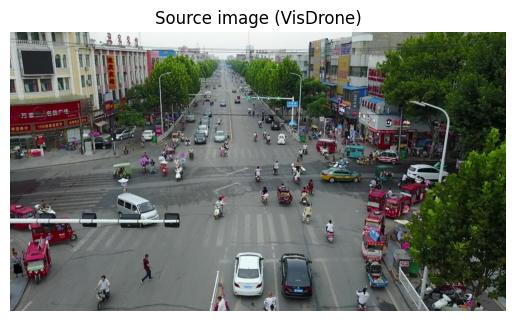

In [3]:
data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)
img_path = os.path.join(data_dir, "visdrone_img.jpg")
if not os.path.isfile(img_path):
    url = "https://data.kitware.com/api/v1/item/623880f14acac99f429fe3ca/download"
    _ = urllib.request.urlretrieve(url, img_path)  # noqa: S310

img_pil = Image.open(img_path)
# Convert to BGR for YOLO compatibility; we'll flip back to RGB for display
img_nd_bgr = np.asarray(img_pil)[:, :, ::-1]

plt.figure()
plt.axis("off")
plt.title("Source image (VisDrone)")
_ = plt.imshow(img_nd_bgr[:, :, ::-1])

### Baseline Detections

We choose a [YOLOv11](https://docs.ultralytics.com/models/yolo11/) object detection model to establish baseline detections. The baseline detections on the unperturbed image serve as our "ground truth" for measuring how perturbations degrade performance.

Ultralytics 8.4.41 🚀 Python-3.13.11 torch-2.11.0+cu130 CPU (12th Gen Intel Core(TM) i9-12900H)


Setup complete ✅ (20 CPUs, 62.5 GB RAM, 697.1/914.7 GB disk)


Computing baseline detections...



0: 384x640 5 persons, 15 cars, 1 motorcycle, 2 trucks, 53.6ms


Speed: 6.4ms preprocess, 53.6ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


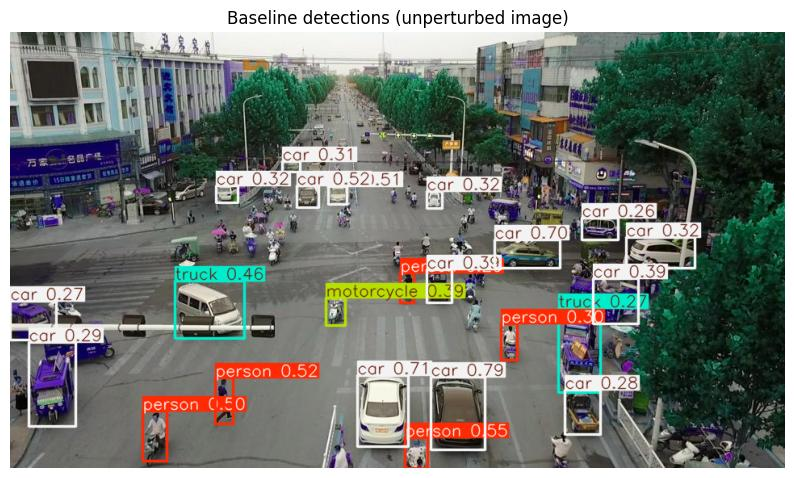

In [4]:
import ultralytics

ultralytics.checks()
print("Downloading model...")
model = ultralytics.YOLO("yolo11n.pt")
print("Computing baseline detections...")
baseline = model(img_nd_bgr)

# Display the source image with baseline detections overlaid
plt.figure(figsize=(10, 6))
plt.axis("off")
plt.title("Baseline detections (unperturbed image)")
_ = plt.imshow(baseline[0].plot())

We can see persons, cars, motorcycles, and trucks — the model detects all of these. The key question: **as we degrade the image, how quickly do these detections fall apart?**

## Part 3: Setting Up the Evaluation Workflow <a name="part-3"></a>

NRTK integrates with [MAITE](https://github.com/mit-ll-ai-technology/maite) to provide a standardized evaluation pipeline. We wrap four components **once**, then reuse them across all perturbation types:

1. **Metric/Evaluation Strategy** — the mAP scoring function
2. **Model** — our YOLO detector, adapted to the MAITE protocol
3. **Dataset** — our source image paired with its baseline detections
4. **Augmentation** — the NRTK perturbation (this is the only part that changes!)

### Metric: Defining our Evaluation Strategy

We'll measure robustness using **mAP@50** — mean Average Precision at an IoU threshold of 0.5.

The approach:
- Run the model on each **perturbed** version of the image
- Compare those detections against the **baseline** (unperturbed) detections
- An mAP of **1.0** means detections are identical to baseline; lower scores indicate degradation

>  We're not asking *"can the model find objects?"* — we're asking *"does the model maintain its performance as conditions change?"*

To accomplish this, we'll wrap TorchMetrics' mAP metric to be compatible with the MAITE workflow:

In [5]:
from maite.protocols import MetricMetadata
from maite.protocols.object_detection import DatumMetadataType
from torchmetrics import Metric as TorchMetric
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# --- MAITE metric wrapper ---


class WrappedTorchmetricsMetric:
    """Wraps a torchmetrics metric for the MAITE evaluation workflow."""

    def __init__(self, tm_metric: TorchMetric) -> None:
        self._tm_metric = tm_metric
        self.metadata = MetricMetadata(id="0")

    @staticmethod
    def to_tensor_dict(target: od.ObjectDetectionTarget) -> dict[str, torch.Tensor]:
        return {
            "boxes": torch.as_tensor(target.boxes),
            "scores": torch.as_tensor(target.scores),
            "labels": torch.as_tensor(target.labels).type(torch.int64),
        }

    def update(
        self,
        preds: Sequence[od.TargetType],
        targets: Sequence[od.TargetType],
        _: Sequence[od.DatumMetadataType],
    ) -> None:
        self._tm_metric.update(
            [self.to_tensor_dict(p) for p in preds],
            [self.to_tensor_dict(t) for t in targets],
        )

    def compute(self) -> dict[str, Any]:
        return self._tm_metric.compute()

    def reset(self) -> None:
        self._tm_metric.reset()


mAP_metric: od.Metric = WrappedTorchmetricsMetric(
    MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
        iou_thresholds=[0.5],
        rec_thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        max_detection_thresholds=[1, 10, 100],
        class_metrics=True,
        extended_summary=False,
        average="macro",
    ),
)

### Model

Next, we'll wrap our YOLO model so that we can use it within the MAITE ecosystem. This includes defining a dataclass to store a single image's bounding boxes, label indices, and confidence scores.

In [6]:
import maite.protocols.object_detection as od
import torch
import ultralytics.models
from maite.protocols import ArrayLike, ModelMetadata

# --- Detection target dataclass ---


@dataclass
class YOLODetectionTarget:
    """Stores bounding boxes, labels, and scores for a single image's detections."""

    boxes: torch.Tensor
    labels: torch.Tensor
    scores: torch.Tensor


# --- MAITE model wrapper ---


class MaiteYOLODetector:
    """Wraps a YOLO model to conform to the MAITE Object Detection Model protocol."""

    def __init__(self, model: ultralytics.models.yolo.model.YOLO) -> None:
        self._model = model
        self.metadata = ModelMetadata(id="0")

    def __call__(self, batch: Sequence[ArrayLike]) -> Sequence[YOLODetectionTarget]:
        batch_transposed = [np.transpose(batch[i], (1, 2, 0)) for i in range(len(batch))]
        yolo_predictions = self._model(batch_transposed, verbose=False)
        return [
            YOLODetectionTarget(
                p.boxes.xyxy.cpu(),
                p.boxes.cls.cpu(),
                p.boxes.conf.cpu(),
            )
            for p in yolo_predictions
        ]


yolo_model: od.Model = MaiteYOLODetector(model)

### Dataset

For demonstration purposes, we'll be running our evaluation against a single image "dataset". Below, we define a minimal MAITE-compliant dataset wrapper — a simple container that serves `(image, detection, metadata)` tuples via `__getitem__` — and instantiate it with our VisDrone image:

In [7]:
from maite.protocols import DatasetMetadata
from maite.protocols.object_detection import Dataset, InputType, TargetType

# --- MAITE dataset wrapper ---

OBJ_DETECTION_DATUM_T = tuple[InputType, TargetType, DatumMetadataType]


class MAITEObjectDetectionDataset(Dataset):
    """MAITE-compliant dataset wrapper for images of varying sizes."""

    def __init__(
        self,
        *,
        imgs: Sequence[np.ndarray[Any, Any]],
        dets: Sequence[TargetType],
        datum_metadata: Sequence[DatumMetadataType],
        dataset_id: str,
        index2label: dict[int, str] | None = None,
    ) -> None:
        self.imgs = imgs
        self.dets = dets
        self.datum_metadata = datum_metadata
        if index2label is not None:
            self.metadata: DatasetMetadata = {
                "id": dataset_id,
                "index2label": index2label,
            }
        else:
            self.metadata = {"id": dataset_id}

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, index: int) -> OBJ_DETECTION_DATUM_T:
        return self.imgs[index], self.dets[index], self.datum_metadata[index]


imgs = [np.transpose(img_nd_bgr, (2, 0, 1))]  # channel-first for MAITE
dets = [
    YOLODetectionTarget(
        baseline[0].boxes.xyxy.cpu(),
        baseline[0].boxes.cls.cpu(),
        baseline[0].boxes.conf.cpu(),
    ),
]
metadata: list[DatumMetadataType] = [{"id": 0}]

single_image_dataset: od.Dataset = MAITEObjectDetectionDataset(
    imgs=imgs,
    dets=dets,
    datum_metadata=metadata,
    dataset_id="visdrone_ex",
)

print("Model, dataset, and metric wrapped for MAITE — ready for evaluation.")

Model, dataset, and metric wrapped for MAITE — ready for evaluation.


### Augmentation

The augmentation is the only thing that will be varying across our pipelines. The MAITE evaluate pipeline will apply the specified perturbation as an augmentation to each image in the provided dataset. Using the built-in adapter, all of NRTK's perturbations are MAITE-compliant:

In [8]:
from nrtk.interop import MAITEObjectDetectionAugmentation

### Evaluation Helper

Since we'll run the same sweep-and-plot pattern for each perturbation type, let's define a helper function. This mirrors what a real T&E workflow would look like — set up once, swap the perturber, repeat.

In [9]:
from maite.tasks import evaluate


def run_sweep(
    augmentations: list,
    perturbation_values: np.ndarray,
    title: str,
    xlabel: str,
    visualization_indices: list[int] | None = None,
) -> list[dict]:
    """Run a perturbation sweep and plot mAP results."""
    if visualization_indices is None:
        visualization_indices = []

    perturbed_metrics = []

    # Visualize selected perturbation levels
    if visualization_indices:
        _, vis_ax = plt.subplots(1, len(visualization_indices), figsize=(8 * len(visualization_indices), 6))
        if len(visualization_indices) == 1:
            vis_ax = [vis_ax]

    # Carry out perturbation sweep
    for idx, a in enumerate(augmentations):
        mAP_metric.reset()
        result, _, _ = evaluate(
            model=yolo_model,
            dataset=single_image_dataset,
            augmentation=a,
            metric=mAP_metric,
        )
        perturbed_metrics.append(result)

        if idx in visualization_indices:
            datum = single_image_dataset[0]
            batch = ([datum[0]], [datum[1]], [datum[2]])
            aug = np.transpose(a(batch)[0][0], (1, 2, 0))
            ax_idx = visualization_indices.index(idx)
            vis_ax[ax_idx].imshow(model(aug)[0].plot())
            vis_ax[ax_idx].set_title(f"{xlabel}: {perturbation_values[idx]:.5g}")
            vis_ax[ax_idx].axis("off")

    if visualization_indices:
        plt.tight_layout()
        plt.show()

    # --- mAP by object size (all sizes + small/medium breakdown) ---
    # COCO size conventions: small < 32x32 px, medium 32x32-96x96 px, large > 96x96 px
    plt.figure(figsize=(9, 4.5))
    plt.title(f"mAP by Object Size — {title}")
    plt.xlabel(xlabel)
    plt.ylabel("mAP")
    styles = {
        "map": {"label": "mAP (all sizes)", "linewidth": 3.0, "linestyle": "-"},
        "map_small": {"label": "mAP (small, <32\u00b2 px)", "linewidth": 1.5, "linestyle": "--"},
        "map_medium": {"label": "mAP (medium, 32\u00b2\u201396\u00b2 px)", "linewidth": 1.5, "linestyle": "--"},
    }
    for k in ("map", "map_small", "map_medium"):
        plt.plot(
            perturbation_values,
            [m[k].item() if m[k].item() >= 0 else 0 for m in perturbed_metrics],
            **styles[k],
        )
    plt.legend()
    plt.tight_layout()
    plt.show()

    return perturbed_metrics

### Sanity Check <a name="sanity-check"></a>

Before running the full perturbation sweeps, we verify the evaluation pipeline works correctly. We create an **identity augmentation** — a perturbation that leaves the image unchanged — and run it through the workflow. Since the image is identical to the original, the model should produce the same detections, giving an mAP of exactly **1.0**.

In [10]:
from nrtk.impls.perturb_image.environment import HazePerturber

identity_augmentation = MAITEObjectDetectionAugmentation(
    augment=HazePerturber(factor=0.0),
    augment_id="identity",
)

sanity_check_results, _, _ = evaluate(
    model=yolo_model,
    dataset=single_image_dataset,
    augmentation=identity_augmentation,
    metric=mAP_metric,
)

print("Sanity check mAP (should be 1.0):", sanity_check_results["map"].item())

Sanity check mAP (should be 1.0): 1.0


## Part 4: Haze — Simulating Fog and Reduced Visibility <a name="part-4"></a>

Our first concern is **fog and haze**. Reduced visibility conditions decrease contrast and obscure scene details — a common problem for outdoor drone operations.

NRTK's `HazePerturber` simulates this with a `factor` parameter:
- `factor = 0.0` — no haze (original image)
- Higher values — progressively thicker haze

An optional `depth_map` controls how haze varies with distance. Without one, the image is treated as a flat plane. We'll create a simple linear gradient to simulate a horizon near the top of the image.

### Running the Haze Evaluation

Now we sweep across a range of haze factors and measure the impact on detection performance.

In [11]:
SWEEP_LOW = 0.0
SWEEP_HIGH = 2.7
SWEEP_COUNT = 30

haze_values = np.linspace(SWEEP_LOW, SWEEP_HIGH, SWEEP_COUNT, endpoint=True)
haze_augmentations = [
    MAITEObjectDetectionAugmentation(augment=HazePerturber(factor=f), augment_id=str(i))
    for i, f in enumerate(haze_values)
]

print(f"Generated {len(haze_augmentations)} haze augmentations (factor {SWEEP_LOW} to {SWEEP_HIGH})")

Generated 30 haze augmentations (factor 0.0 to 2.7)


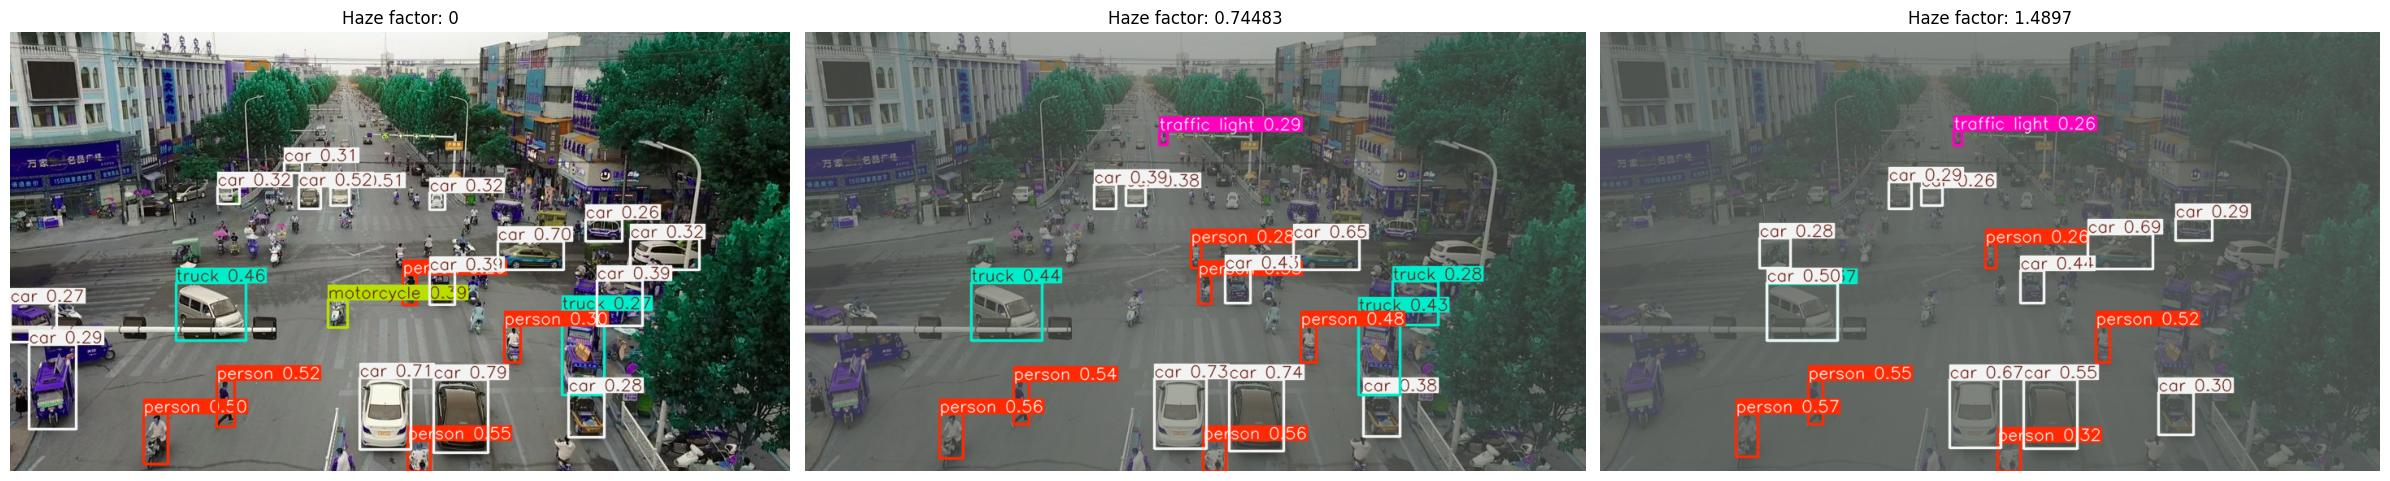

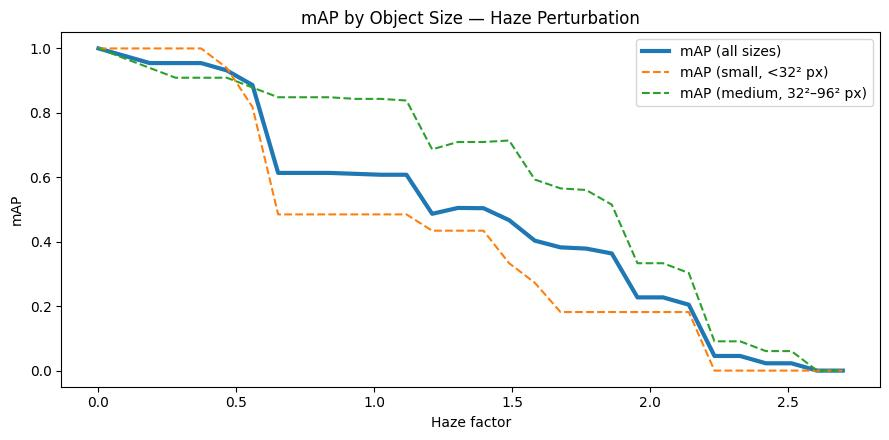

In [12]:
haze_metrics = run_sweep(
    augmentations=haze_augmentations,
    perturbation_values=haze_values,
    title="Haze Perturbation",
    xlabel="Haze factor",
    visualization_indices=[0, 8, 16],
)

### What We Learned: Haze

Key observations:
- mAP falls off nearly linearly with the haze factor, reaching zero around factor 2.5
- **Depth matters more than class:** Our depth map places the densest fog at the horizon, so objects near the bottom of the frame stay detectable well into the sweep
- At the per-area level, medium objects hold up much better than small objects

> **For our T&E report:** *"The model handles light haze, but moderate fog (factor ~1.0) already erases small and background detections. Operations above factor 1.5 would require mitigation or targeted fine-tuning."*

## Part 5: Water Droplets — Simulating Rain on the Lens <a name="part-5"></a>

Finally, we test **water droplets on the lens** — a common problem for outdoor cameras, especially in maritime or rainy environments. Droplets create localized refraction patterns that distort image regions.

NRTK's `WaterDropletPerturber` simulates this. The key parameter for sweeping is `num_drops`:
- `num_drops = 0` — no droplets
- Higher values — more droplets, more occlusion

### Running the Water Droplet Evaluation

Now we sweep across a range of water droplets and measure the impact on detection performance.

In [13]:
from nrtk.impls.perturb_image.environment import WaterDropletPerturber

SWEEP_LOW_W = 0
SWEEP_HIGH_W = 275
SWEEP_COUNT_W = 15

drop_values = np.linspace(SWEEP_LOW_W, SWEEP_HIGH_W, SWEEP_COUNT_W, endpoint=True)
drop_augmentations = [
    MAITEObjectDetectionAugmentation(
        augment=WaterDropletPerturber(num_drops=int(n), size_range=[1.0, 2.0], seed=0),
        augment_id=str(i),
    )
    for i, n in enumerate(drop_values)
]

print(
    f"Generated {len(drop_augmentations)} water droplet augmentations ({int(SWEEP_LOW_W)} to {int(SWEEP_HIGH_W)} drops)",
)

Generated 15 water droplet augmentations (0 to 275 drops)


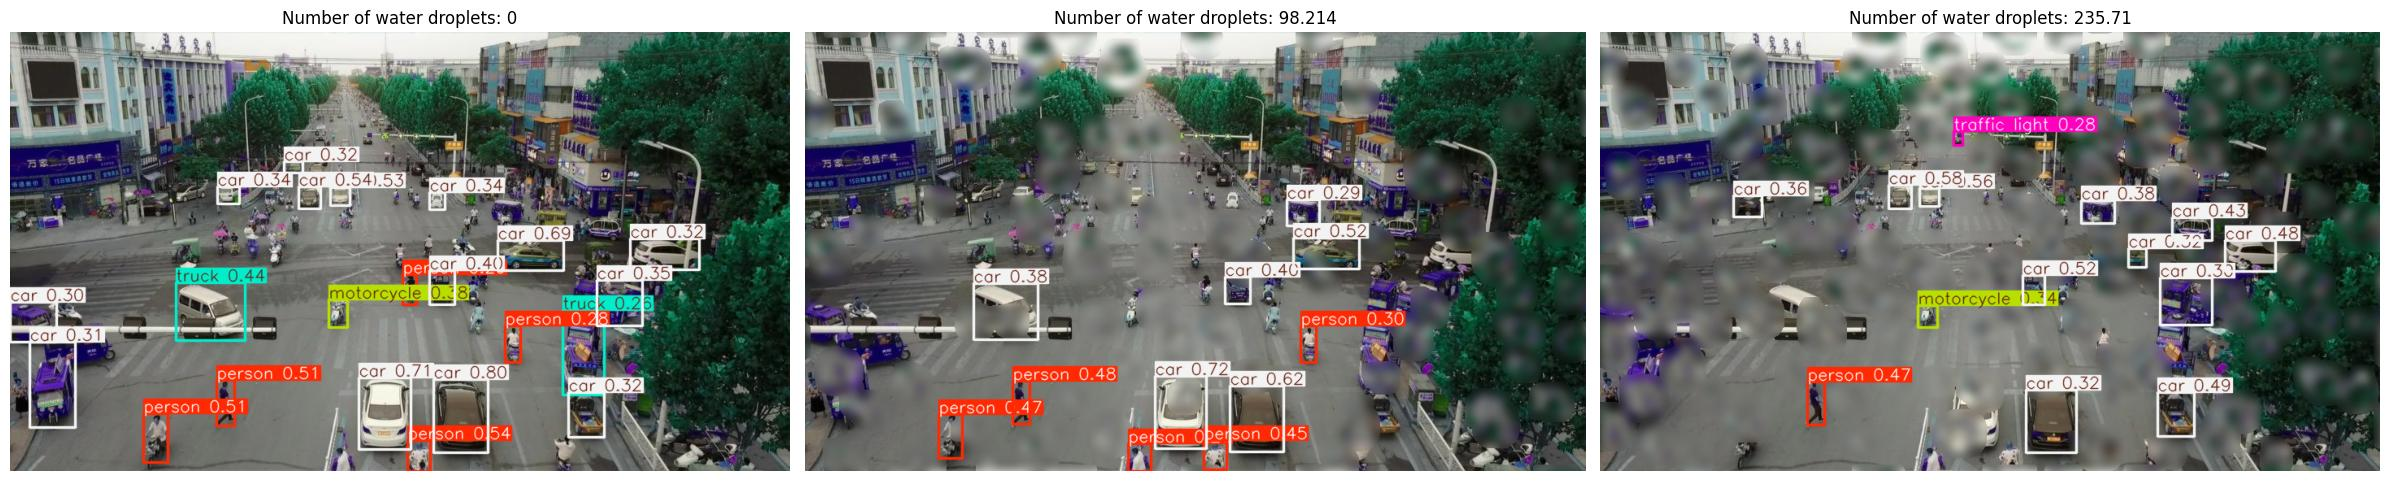

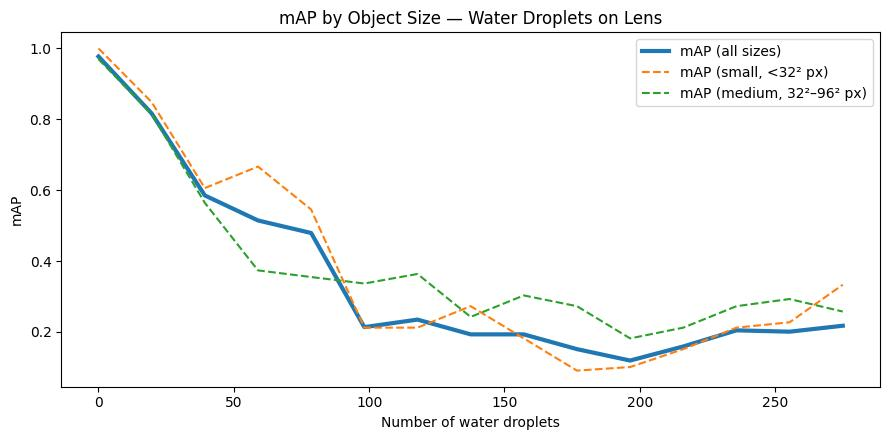

In [14]:
drop_metrics = run_sweep(
    augmentations=drop_augmentations,
    perturbation_values=drop_values,
    title="Water Droplets on Lens",
    xlabel="Number of water droplets",
    visualization_indices=[0, 5, 12],
)

### What We Learned: Water Droplets

Key observations:
- mAP declines with droplet count, but the curve is **noisier** than haze — where the droplets land matters as much as how many there are
- Even fully visible objects can be missed if surrounding context is blurred by nearby droplets

> **For our report:** *"Droplet degradation is partly stochastic — two runs with the same count can give different results depending on placement. Validate with multiple random seeds. Maritime operations should also include lens-cleaning protocols or hydrophobic coatings."*

## Going Further: Additional Perturbation Types <a name="going-further"></a>

We demonstrated two perturbation types today, but NRTK provides a full catalog — each mapping to a real-world operational risk:

| Operational Risk | NRTK Perturber | Key Parameters | Extra(s) |
|---|---|---|---|
| Extreme Illumination | `BrightnessPerturber` | `factor` | `pillow` |
| High-Frequency Vibration | `JitterPerturber` | `s_x`, `s_y` (jitter amplitudes) | `pybsm` |
| Target Out of Focus | `DefocusPerturber` | `w_x`, `w_y` (blur strength) | `pybsm` |
| Sensor Resolution / Noise | `PybsmPerturber` | `p_x` (pixel pitch), `bit_depth` | `pybsm` |
| Atmospheric Turbulence | `TurbulenceAperturePerturber` | `cn2_at_1m` | `pybsm` |
| **Mist / Fog / Snow** | **`HazePerturber`** | **`factor`, `depth_map`** | *(core)* |
| **Water Droplets on Lens** | **`WaterDropletPerturber`** | **`num_drops`, `size_range`** | **`waterdroplet`** |
| Radial Distortion | `RadialDistortionPerturber` | `k1`, `k2`, `k3` | `headless` |
| Lens Flare | `AlbumentationsPerturber` | (wraps RandomSunFlare) | `albumentations` |

Each can be plugged into the **exact same evaluation workflow** — swap the perturber, adjust the sweep range, and call `run_sweep()`. The model wrapping, dataset, metrics, and analysis infrastructure stays identical.

For detailed examples of each, see the [NRTK T&E Guides](https://nrtk.readthedocs.io/en/latest/tutorials/testing_and_evaluation_notebooks.html).

### Physics-Based Sensor Simulation

The `pybsm`-backed perturbers (Jitter, Defocus, PybsmPerturber, Turbulence) are particularly powerful because they model the actual physics of image formation — telescope optics, detector characteristics, atmospheric effects. This means you can answer questions like:

- *"If we downgrade from a 16-bit to an 8-bit sensor, will the model still work?"*
- *"At what altitude does atmospheric turbulence start to degrade detection accuracy?"*
- *"How much platform jitter can the model tolerate before we need stabilization hardware?"*

These are **sensor design** questions that NRTK can help answer before hardware is built or purchased.

## Resources & Next Steps <a name="resources"></a>

### What to Try Next

1. **Run the T&E guide notebooks** — Each one walks through a different perturbation type with the same workflow pattern you learned today
2. **Swap in your own model** — Replace the YOLO wrapper with your own detector or classifier
3. **Use your own imagery** — Load your operational test data instead of VisDrone
4. **Explore sensor simulation** — Try the sensor transformation notebook for resolution and noise analysis
5. **Try nrtk-explorer** — An interactive web UI for exploring perturbation effects visually

### Links

| Resource | URL |
|---|---|
| NRTK Documentation | [nrtk.readthedocs.io](https://nrtk.readthedocs.io) |
| NRTK GitHub | [github.com/Kitware/nrtk](https://github.com/Kitware/nrtk) |
| NRTK PyPI | [pypi.org/project/nrtk](https://pypi.org/project/nrtk/) |
| T&E Guide Notebooks | [T&E Guides with MAITE](<project:/tutorials/testing_and_evaluation_notebooks.rst>) |
| Operational Risk Factors | [Risk Factors](<project:/explanations/risk_factors.rst>) |
| MAITE (Modular AI Trustworthy Engineering) | [github.com/mit-ll-ai-technology/maite](https://github.com/mit-ll-ai-technology/maite) |
| pyBSM Sensor Modeling | [pybsm.readthedocs.io](https://pybsm.readthedocs.io) |
| nrtk-explorer (Interactive UI) | [github.com/Kitware/nrtk-explorer](https://github.com/Kitware/nrtk-explorer) |

### Contact

Questions? Reach out at **[nrtk@kitware.com](mailto:nrtk@kitware.com)** or open an issue on [GitHub](https://github.com/Kitware/nrtk/issues).

---

*This material is based upon work supported by the Chief Digital and Artificial Intelligence Office under Contract No. 519TC-23-9-2032.*